# RL Comparison: DDPG vs Dueling Double DQN
### Environment: `MountainCarContinuous-v0`

Both agents run on the **same environment** so results are directly comparable.

| | DDPG | Dueling Double DQN |
|---|---|---|
| **Action space** | Continuous (native) | Discretized into N bins |
| **Actor/Policy** | Deterministic policy net | ε-greedy over Q-values |
| **Critic** | Q(s,a) MLP | Dueling V(s) + A(s,a) MLP |
| **Target update** | Periodic hard copy | Periodic hard copy |
| **Replay buffer** | Shared `ReplayBuffer` class | Shared `ReplayBuffer` class |

## 1. Imports & Shared Setup

In [2]:
import numpy as np
import gymnasium as gym
import torch
from torch import nn
import torch.nn.functional as F
import random
from collections import deque
import copy
import math
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.std import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 2. Environment, Shared Replay Buffer & Episode Runner

In [3]:
# ── Environment (same for BOTH agents) ──────────────────────────────────────
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
n_state  = int(np.prod(env.observation_space.shape))  # 2
n_action = int(np.prod(env.action_space.shape))        # 1
act_lim  = float(env.action_space.high[0])             # 1.0

# DQN discretises the single continuous action axis into N_BINS bins
N_BINS      = 11
action_bins = np.linspace(-act_lim, act_lim, N_BINS)  # [-1.0, -0.8, ..., 1.0]

print(f'State dim : {n_state}')
print(f'Action dim: {n_action}  (continuous, limit ±{act_lim})')
print(f'DQN bins  : {action_bins}')

State dim : 2
Action dim: 1  (continuous, limit ±1.0)
DQN bins  : [-1.  -0.8 -0.6 -0.4 -0.2  0.   0.2  0.4  0.6  0.8  1. ]


In [4]:
# ── Shared Replay Buffer ─────────────────────────────────────────────────────
# Used by both agents.
#   DDPG stores float32 action vectors.
#   DQN  stores integer bin indices (as float32 so the same buffer works).

class ReplayBuffer:
    def __init__(self, size):
        self.buff = deque(maxlen=size)

    def add(self, obs, act, reward, next_obs, done):
        self.buff.append([obs, act, reward, next_obs, done])

    def sample(self, sample_size):
        if len(self.buff) < sample_size:
            sample_size = len(self.buff)
        sample   = random.sample(self.buff, sample_size)
        obs      = torch.FloatTensor(np.array([e[0] for e in sample])).to(device)
        act      = torch.FloatTensor(np.array([e[1] for e in sample])).to(device)
        reward   = torch.FloatTensor([e[2] for e in sample]).to(device)
        next_obs = torch.FloatTensor(np.array([e[3] for e in sample])).to(device)
        done     = torch.FloatTensor([e[4] for e in sample]).to(device)
        return obs, act, reward, next_obs, done

    def __len__(self):
        return len(self.buff)

In [5]:
# ── Shared episode runner ────────────────────────────────────────────────────
def run_episode(env, policy, noise=False):
    """Runs one episode; policy(obs, noise) must return a float32 action array."""
    obs, _ = env.reset()
    states, actions, rewards = [], [], []
    while True:
        states.append(obs)
        action = policy(obs, noise=noise)
        actions.append(action)
        obs, reward, terminated, truncated, _ = env.step(action)
        rewards.append(reward)
        if terminated or truncated:
            break
    return states, actions, rewards

---
## 3. Agent 1 — DDPG
*(Original code — only reformatted, no logic changes)*

In [6]:
class DDPGPolicy:
    def __init__(self, n_state, n_action, noise):
        self.n_state  = n_state
        self.n_action = n_action
        self.noise    = noise
        self.gamma    = 0.95
        self.act_lim  = float(env.action_space.high[0])

        # ── Critic Q(s, a) ───────────────────────────────────────────────
        self.q_net = nn.Sequential(
            nn.Linear(n_state + n_action, 400), nn.ReLU(),
            nn.Linear(400, 300),                nn.ReLU(),
            nn.Linear(300, 1)
        )

        # ── Actor π(s) ───────────────────────────────────────────────────
        self.act_net = nn.Sequential(
            nn.Linear(n_state, 400), nn.ReLU(),
            nn.Linear(400, 300),     nn.ReLU(),
            nn.Linear(300, n_action), nn.Tanh()   # output in [-1, 1]
        )

        self.target_act_net = copy.deepcopy(self.act_net)
        self.target_q_net   = copy.deepcopy(self.q_net)

        self.act_optimizer = torch.optim.Adam(self.act_net.parameters(), lr=1e-3)
        self.q_optimizer   = torch.optim.Adam(self.q_net.parameters(),   lr=1e-3)

        for net in [self.act_net, self.q_net,
                    self.target_act_net, self.target_q_net]:
            net.to(device)

        self.replaybuff         = ReplayBuffer(50000)
        self.update_counter     = 0
        self.target_update_freq = 5

    def update(self):
        obs, act, reward, next_obs, done = self.replaybuff.sample(64)

        # Critic update
        self.q_optimizer.zero_grad()
        with torch.no_grad():
            q_input = torch.cat(
                [next_obs, self.act_lim * self.target_act_net(next_obs)], dim=1)
            y = reward + self.gamma * (1 - done) * \
                self.target_q_net(q_input).squeeze()
        q_pred = self.q_net(torch.cat([obs, act], dim=1)).squeeze()
        loss_q = F.mse_loss(q_pred, y)
        loss_q.backward()
        self.q_optimizer.step()

        # Actor update
        self.act_optimizer.zero_grad()
        loss_act = -self.q_net(
            torch.cat([obs, self.act_lim * self.act_net(obs)], dim=1)
        ).mean()
        loss_act.backward()
        self.act_optimizer.step()

        # Periodic hard target copy
        self.update_counter += 1
        if self.update_counter % self.target_update_freq == 0:
            self.target_q_net.load_state_dict(self.q_net.state_dict())
            self.target_act_net.load_state_dict(self.act_net.state_dict())

        return loss_q.item(), loss_act.item()

    def __call__(self, state, noise=True):
        if not torch.is_tensor(state):
            state = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            act = (self.act_lim * self.act_net(state)).cpu().numpy()[0]
        if noise:
            act += self.noise * np.random.randn(self.n_action)
            act  = np.clip(act, -self.act_lim, self.act_lim)
        return act.astype(np.float32)

In [7]:
# ── DDPG Training Loop ───────────────────────────────────────────────────────
DDPG_EPISODES  = 2000
DDPG_UPDATE_FREQ = 10
DDPG_MIN_BUFFER  = 2000

ddpg_losses_q, ddpg_losses_act, ddpg_rewards = [], [], []
ddpg_policy  = DDPGPolicy(n_state, n_action, noise=2)
loss_q, loss_act = 0.0, 0.0
update_index = 0

for i in tqdm(range(DDPG_EPISODES), desc='DDPG'):
    obs, _ = env.reset()
    ep_reward = 0

    while True:
        act = ddpg_policy(obs, noise=True)
        next_obs, reward, terminated, truncated, _ = env.step(act)
        done = terminated or truncated
        ep_reward   += reward
        update_index += 1

        ddpg_policy.replaybuff.add(obs, act, reward, next_obs, done)

        if (len(ddpg_policy.replaybuff) > DDPG_MIN_BUFFER
                and update_index % DDPG_UPDATE_FREQ == 0):
            loss_q, loss_act = ddpg_policy.update()

        obs = next_obs
        if done:
            break

    if i > 0 and i % 100 == 0:
        print(f'DDPG  itr:{i:>5d}  '
              f'q_loss:{np.mean(ddpg_losses_q[-100:]):>7.4f}  '
              f'act_loss:{np.mean(ddpg_losses_act[-100:]):>7.4f}  '
              f'reward:{np.mean(ddpg_rewards[-100:]):>7.1f}  '
              f'noise:{ddpg_policy.noise:>5.3f}')

    if ddpg_policy.noise > 0.005:
        ddpg_policy.noise -= (1 / 200)

    ddpg_losses_q.append(loss_q)
    ddpg_losses_act.append(loss_act)
    ddpg_rewards.append(ep_reward)

print('DDPG training complete.')

DDPG:   5%|▌         | 101/2000 [01:06<06:47,  4.66it/s]

DDPG  itr:  100  q_loss: 1.9490  act_loss:-6.2758  reward:   32.2  noise:1.500


DDPG:  10%|█         | 202/2000 [01:26<05:16,  5.67it/s]

DDPG  itr:  200  q_loss: 1.5088  act_loss:-12.7886  reward:   89.3  noise:1.000


DDPG:  15%|█▌        | 301/2000 [01:40<03:09,  8.94it/s]

...

DDPG  itr: 1800  q_loss: 0.0983  act_loss:-25.9612  reward:   94.0  noise:0.000


DDPG:  95%|█████████▌| 1903/2000 [04:10<00:08, 11.71it/s]

DDPG  itr: 1900  q_loss: 0.0876  act_loss:-27.0157  reward:   93.9  noise:0.000


DDPG: 100%|██████████| 2000/2000 [04:21<00:00,  7.64it/s]

DDPG training complete.


In [8]:
# ── DDPG Final Evaluation ────────────────────────────────────────────────────
ddpg_policy.noise = 0.0
ddpg_eval_scores  = [sum(run_episode(env, ddpg_policy, noise=False)[2])
                     for _ in range(100)]
print(f'DDPG final score (mean over 100 eps): {np.mean(ddpg_eval_scores):.2f}')

DDPG final score (mean over 100 eps): 94.18


---
## 4. Agent 2 — Dueling Double DQN

The Atari CNN is replaced with an MLP (same layer widths as DDPG: 400→300)
because MountainCar has only a 2-dimensional state. Everything else is
preserved from the original:
- **Dueling heads** V(s) and A(s, a)
- **Double DQN** target computation
- **Huber loss** (`SmoothL1Loss`)
- **ε-greedy** exploration with the same decay schedule
- **Hard target copy** every `DQN_TARGET_FREQ` steps

In [9]:
class DuelingDQN(nn.Module):
    """Dueling DQN with MLP backbone for low-dimensional state.

    The Atari CNN is swapped out for two FC layers (400, 300) matching
    the DDPG network widths. The Dueling V/A heads and weight init
    are kept exactly as in the original Pong implementation.
    """
    def __init__(self, n_state, num_actions):
        super().__init__()

        # ── Shared trunk (replaces CNN) ──────────────────────────────────
        self.fc1 = nn.Linear(n_state, 400)
        nn.init.normal_(self.fc1.weight, mean=0.0, std=math.sqrt(2.0 / n_state))
        self.fc1.bias.data.fill_(0.0)

        self.fc2 = nn.Linear(400, 300)
        nn.init.normal_(self.fc2.weight, mean=0.0, std=math.sqrt(2.0 / 400))
        self.fc2.bias.data.fill_(0.0)

        # ── Dueling heads (unchanged from original) ──────────────────────
        self.V = nn.Linear(300, 1)            # state value
        self.A = nn.Linear(300, num_actions)  # advantage per action-bin

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        V = self.V(x)
        A = self.A(x)
        return V + (A - A.mean(dim=1, keepdim=True))  # Q = V + (A - mean(A))

In [17]:
# ── DQN helper functions (identical logic to original) ────────────────────────

def select_epsilon_greedy_action(main_nn, state_tensor, epsilon):
    """Random action with probability epsilon, else argmax Q."""
    if np.random.uniform() < epsilon:
        return np.random.randint(N_BINS)
    qs = main_nn(state_tensor).cpu().data.numpy()
    return int(np.argmax(qs))


def bin_to_action(bin_idx):
    """Map a discrete bin index → continuous float32 action."""
    return np.array([action_bins[bin_idx]], dtype=np.float32)


# Huber loss — same as original
dqn_loss_fn = nn.SmoothL1Loss()


def dqn_train_step(main_nn, target_nn, optimizer,
                   states, actions, rewards, next_states, dones, discount):
    """Double DQN update — identical to original train_step."""
    actions = actions.long()  # bin indices must be ints for gather()

    # Double DQN: SELECT with main_nn, EVALUATE with target_nn
    next_qs_argmax = main_nn(next_states).argmax(dim=-1, keepdim=True)
    masked_next_qs = target_nn(next_states).gather(1, next_qs_argmax).squeeze()
    target         = rewards + (1.0 - dones) * discount * masked_next_qs

    masked_qs = main_nn(states).gather(1, actions.squeeze(-1).unsqueeze(-1)).squeeze()    
    loss      = dqn_loss_fn(masked_qs, target.detach())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

In [18]:
# ── DQN Hyperparameters (from original Pong code) ────────────────────────────
DQN_EPISODES   = 2000
DQN_EPSILON    = 1.0
DQN_BATCH_SIZE = 32
DQN_DISCOUNT   = 0.99
DQN_BUFFER_SIZE = 200000
DQN_TARGET_FREQ = 10000  # hard copy every N environment steps
DQN_MIN_BUFFER  = 2000

dqn_main   = DuelingDQN(n_state, N_BINS).to(device)
dqn_target = DuelingDQN(n_state, N_BINS).to(device)
dqn_target.load_state_dict(dqn_main.state_dict())

dqn_optimizer = torch.optim.Adam(dqn_main.parameters(), lr=1e-5)  # same lr as original
dqn_buffer    = ReplayBuffer(DQN_BUFFER_SIZE)   # reuses shared class

In [19]:
# ── Thin wrapper so run_episode() works with DQN too ─────────────────────────
class DQNPolicy:
    def __init__(self, main_nn, epsilon=0.0):
        self.main_nn = main_nn
        self.epsilon = epsilon

    def __call__(self, state, noise=False):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        eps     = self.epsilon if noise else 0.0
        bin_idx = select_epsilon_greedy_action(self.main_nn, state_t, eps)
        return bin_to_action(bin_idx)

In [20]:
# ── Dueling DQN Training Loop ────────────────────────────────────────────────
dqn_losses, dqn_rewards = [], []
dqn_epsilon = DQN_EPSILON
dqn_loss    = 0.0
cur_frame   = 0
last_100    = []

for episode in tqdm(range(DQN_EPISODES), desc='DuelingDQN'):
    obs, _    = env.reset()
    ep_reward = 0
    done      = False

    while not done:
        state_t  = torch.FloatTensor(obs).unsqueeze(0).to(device)
        bin_idx  = select_epsilon_greedy_action(dqn_main, state_t, dqn_epsilon)
        act_cont = bin_to_action(bin_idx)

        next_obs, reward, terminated, truncated, _ = env.step(act_cont)
        done       = terminated or truncated
        ep_reward += reward

        # Store bin index as float32 so the shared ReplayBuffer works
        dqn_buffer.add(obs,
                       np.array([bin_idx], dtype=np.float32),
                       reward, next_obs, float(done))
        obs        = next_obs
        cur_frame += 1

        # Epsilon decay (same schedule as original)
        if dqn_epsilon > 0.01:
            dqn_epsilon -= 1.1e-6

        # Train
        if len(dqn_buffer) >= max(DQN_BATCH_SIZE, DQN_MIN_BUFFER):
            states_b, actions_b, rewards_b, next_states_b, dones_b = \
                dqn_buffer.sample(DQN_BATCH_SIZE)
            dqn_loss = dqn_train_step(
                dqn_main, dqn_target, dqn_optimizer,
                states_b, actions_b, rewards_b, next_states_b, dones_b,
                DQN_DISCOUNT
            )

        # Hard target copy every DQN_TARGET_FREQ steps
        if cur_frame % DQN_TARGET_FREQ == 0:
            dqn_target.load_state_dict(dqn_main.state_dict())

    last_100.append(ep_reward)
    if len(last_100) > 100:
        last_100 = last_100[1:]

    if episode % 25 == 0:
        print(f'DQN  episode:{episode}/{DQN_EPISODES}  '
              f'epsilon:{dqn_epsilon:.4f}  '
              f'loss:{dqn_loss:.4f}  '
              f'mean100:{np.mean(last_100):.2f}')

    dqn_losses.append(dqn_loss)
    dqn_rewards.append(ep_reward)

print('Dueling DQN training complete.')

DuelingDQN:   0%|          | 1/2000 [00:00<03:22,  9.86it/s]

DQN  episode:0/2000  epsilon:0.9991  loss:0.0000  mean100:66.79


DuelingDQN:   1%|▏         | 26/2000 [02:26<3:22:04,  6.14s/it]

DQN  episode:25/2000  epsilon:0.9716  loss:0.0000  mean100:-35.46


DuelingDQN:   3%|▎         | 51/2000 [05:02<3:25:35,  6.33s/it]

...

DQN  episode:1950/2000  epsilon:0.0465  loss:0.2259  mean100:93.87


DuelingDQN:  99%|█████████▉| 1976/2000 [1:31:27<00:11,  2.05it/s]

DQN  episode:1975/2000  epsilon:0.0441  loss:0.7570  mean100:93.88


DuelingDQN: 100%|██████████| 2000/2000 [1:31:40<00:00,  2.75s/it]

Dueling DQN training complete.


In [21]:
# ── DQN Final Evaluation ─────────────────────────────────────────────────────
dqn_policy_eval = DQNPolicy(dqn_main, epsilon=0.0)
dqn_eval_scores = [sum(run_episode(env, dqn_policy_eval, noise=False)[2])
                   for _ in range(100)]
print(f'DuelingDQN final score (mean over 100 eps): {np.mean(dqn_eval_scores):.2f}')

DuelingDQN final score (mean over 100 eps): 93.92


---
## 5. Results — Side-by-Side Comparison

/tmp/ipykernel_2527488/2104196342.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ddpg_eval_scores, dqn_eval_scores],


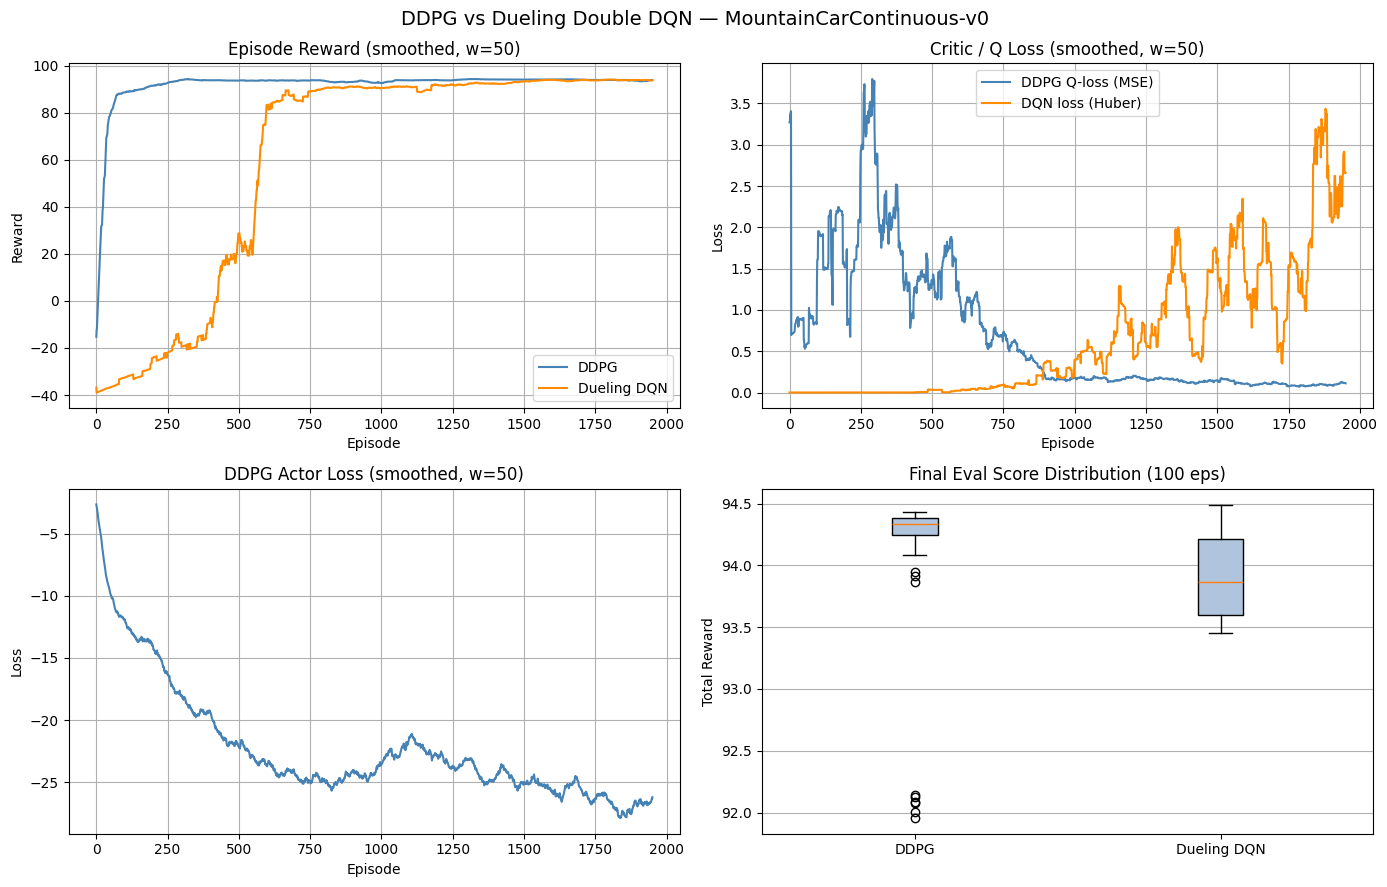

In [22]:
def smooth(x, w=50):
    return np.convolve(x, np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('DDPG vs Dueling Double DQN — MountainCarContinuous-v0', fontsize=14)

# Reward curves
ax = axes[0, 0]
ax.plot(smooth(ddpg_rewards), label='DDPG',        color='steelblue')
ax.plot(smooth(dqn_rewards),  label='Dueling DQN', color='darkorange')
ax.set_title('Episode Reward (smoothed, w=50)')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
ax.legend(); ax.grid(True)

# Critic / Q-loss
ax = axes[0, 1]
ax.plot(smooth(ddpg_losses_q), label='DDPG Q-loss (MSE)',   color='steelblue')
ax.plot(smooth(dqn_losses),    label='DQN loss (Huber)',    color='darkorange')
ax.set_title('Critic / Q Loss (smoothed, w=50)')
ax.set_xlabel('Episode'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True)

# DDPG actor loss
ax = axes[1, 0]
ax.plot(smooth(ddpg_losses_act), color='steelblue')
ax.set_title('DDPG Actor Loss (smoothed, w=50)')
ax.set_xlabel('Episode'); ax.set_ylabel('Loss')
ax.grid(True)

# Eval distribution
ax = axes[1, 1]
ax.boxplot([ddpg_eval_scores, dqn_eval_scores],
           labels=['DDPG', 'Dueling DQN'],
           patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'))
ax.set_title('Final Eval Score Distribution (100 eps)')
ax.set_ylabel('Total Reward')
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('rl_comparison.png', dpi=150)
plt.show()

In [23]:
# ── Save training logs ────────────────────────────────────────────────────────
pd.DataFrame({
    'ddpg_q_loss':   ddpg_losses_q,
    'ddpg_act_loss': ddpg_losses_act,
    'ddpg_reward':   ddpg_rewards,
    'dqn_loss':      dqn_losses,
    'dqn_reward':    dqn_rewards,
}).to_csv('rl_comparison.csv', index=False)

print('Saved rl_comparison.csv')
print(f'\nFinal Results:')
print(f'  DDPG        — mean eval reward: {np.mean(ddpg_eval_scores):>8.2f}')
print(f'  Dueling DQN — mean eval reward: {np.mean(dqn_eval_scores):>8.2f}')

env.close()

Saved rl_comparison.csv

Final Results:
  DDPG        — mean eval reward:    94.18
  Dueling DQN — mean eval reward:    93.92
